In [1]:
# Import system
import sys
sys.path.append('../')
# Import native packages
import matplotlib.pyplot as plt

from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.simulation import MonteCarloWithTraining as Mcs
from stockhealth.training import Trends

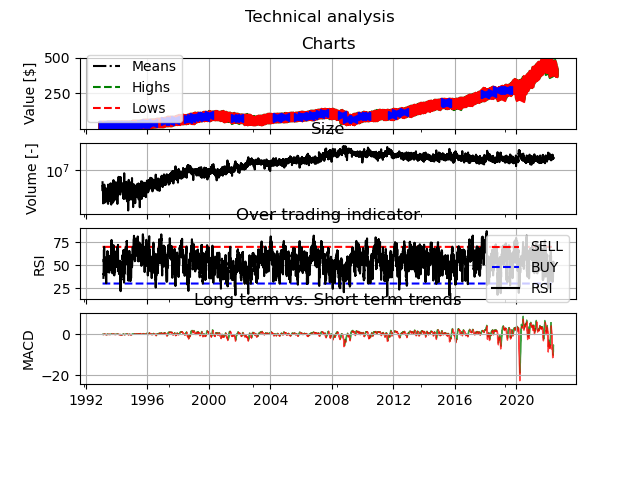

In [2]:
stock = Ts(ticker='SPY')

%matplotlib widget
f, a = stock.technical()

In [3]:
stock = Ts(ticker='SPY')
df = stock.history__

In [4]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Increase [%],Intra-day volatility,Real Worth,Risk free return,Volatility,Perkinson Volatility
Date,,,,,,,,,,,,,
1993-01-29,25.566146,25.566146,25.438951,25.547976,1003200,0.0,0,NaN,0.004975,25.566146,0.000000,0.004975,0.006054
1993-02-01,25.566156,25.729692,25.566156,25.729692,480500,0.0,0,0.710771,0.006397,25.729692,0.006397,0.007113,0.007217
1993-02-02,25.711516,25.802369,25.657004,25.784199,201300,0.0,0,0.211992,0.005654,25.784199,0.002118,0.005650,0.006444
1993-02-03,25.820540,26.074930,25.802369,26.056759,529400,0.0,0,1.055594,0.010556,26.056759,0.010571,0.011276,0.009077
1993-02-04,26.147620,26.220303,25.856889,26.165791,531500,0.0,0,0.416985,0.013899,26.165791,0.004184,0.013947,0.010128
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-05-24,392.559998,395.149994,386.959991,393.890015,91448800,0.0,0,-0.771856,0.020863,475.741015,-0.006329,0.025093,0.013666
2022-05-25,392.309998,399.450012,391.890015,397.369995,91472900,0.0,0,0.887049,0.019270,479.220995,0.007315,0.019193,0.011850
2022-05-26,398.670013,407.040009,398.450012,405.309998,82168300,0.0,0,1.991623,0.021547,487.160998,0.016569,0.024335,0.013293


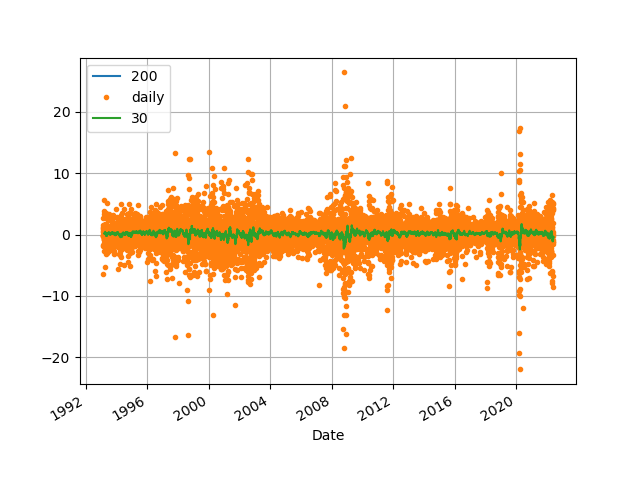

In [5]:
%matplotlib widget
axs = (df['Risk free return'] * 254).rolling(window=200).mean().plot(label=200)
(df['Risk free return'] * 254).plot(label='daily', style='.')
(df['Risk free return'] * 254).rolling(window=30).mean().plot(ax=axs, label=30, grid=True)
axs.legend()

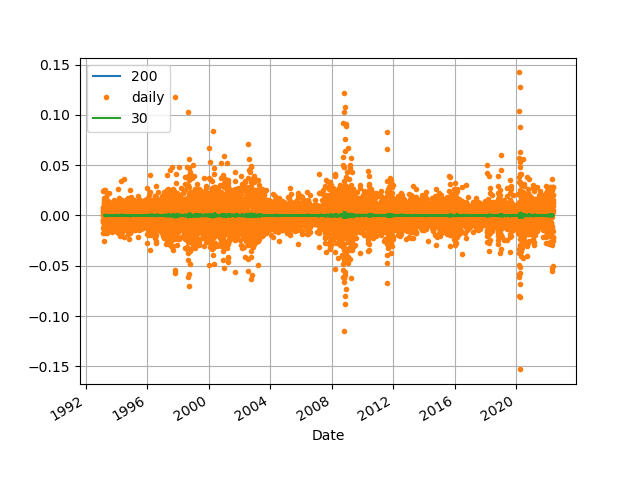

In [6]:
%matplotlib widget
axs = (df['Risk free return']).rolling(window=200).mean().diff().plot(label=200)
(df['Risk free return']).diff().plot(label='daily', style='.')
(df['Risk free return']).rolling(window=30).mean().diff().plot(ax=axs, label=30, grid=True)
axs.legend()

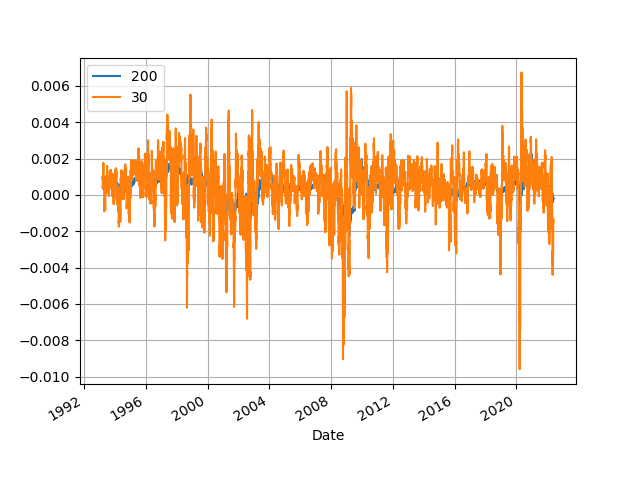

In [7]:
%matplotlib widget
axs = (df['Risk free return']).rolling(window=200).mean().plot(label=200)
#(df['Risk free return']).plot(label='daily', style='.')
(df['Risk free return']).rolling(window=30).mean().plot(ax=axs, label=30, grid=True)
axs.legend()

In [8]:
df['Risk free return'].rolling(window=200).mean().mean()
df['Risk free return'].rolling(window=30).mean().mean()
df['Risk free return'].mean()

X = df['Risk free return'].rolling(window=30).mean() - df['Risk free return'].rolling(window=200).mean()
Y = X.diff(periods=1)
Z = Y.diff(periods=1)

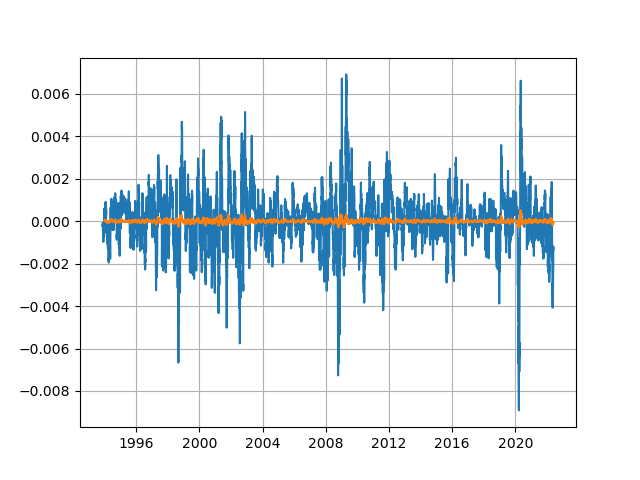

In [9]:
%matplotlib widget
#plt.plot(Y, Z, '.k')
plt.plot(X)
plt.plot(Y.rolling(window=30).mean())
plt.grid(True)

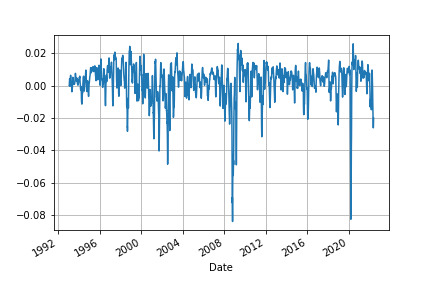

In [18]:
%matplotlib widget
newaxs = (stock.macd()['Signal'] / stock.history__['Close']).plot(grid=True)

In [19]:
X = (stock.macd()['MACD'] / stock.history__['Close'])
Y = (stock.macd()['Signal'] / stock.history__['Close'])

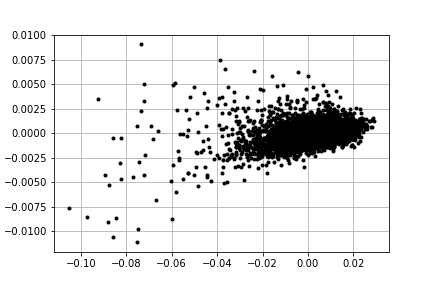

In [27]:
%matplotlib widget
plt.plot(X, Y.diff(), '.k')
plt.grid(True)